In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("./data/now_final.csv")

print("=" * 50)
print("Dataset shape")
print("=" * 50)

print(df.shape)

print("\nColumns:\n")
print(df.columns.tolist())

Dataset shape
(35539, 34)

Columns:

['pcap_id', 'sample_hash', 'label', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'duration', 'total_bytes', 'total_packets', 'bytes_per_second', 'packets_per_second', 'pkt_len_mean', 'pkt_len_std', 'iat_mean', 'iat_std', 'burstiness', 'burst_count', 'is_complete_handshake', 'has_tls', 'tls_cipher_count', 'tls_ext_count', 'ja4_fingerprint', 'ja4_tls_ver_num', 'ja4_cipher_count', 'ja4_ext_count', 'ja4_sni_present', 'ja4_has_alpn', 'ja3_fingerprint', 'dns_query_count', 'dns_unique_queries', 'http_request_count', 'http_unique_hosts']



Flows per label:

label
emotet      11997
bengin      11801
trickbot    11741
Name: count, dtype: int64


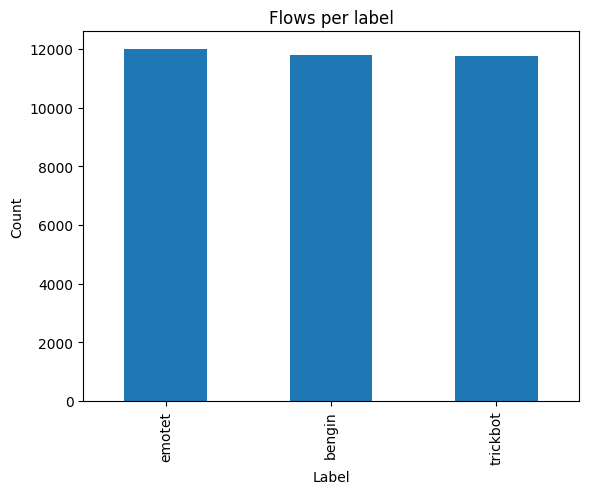

In [29]:
print("\nFlows per label:\n")

print(df["label"].value_counts())

df["label"].value_counts().plot(kind="bar")

plt.title("Flows per label")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()


Unique JA4 fingerprints per label:

label
bengin      27
emotet      10
trickbot    10
Name: ja4_fingerprint, dtype: int64
ja4_fingerprint
t10i120300_d94e65cdb899_5f12c91e28fe    1035
t13d1516h2_8daaf6152771_d8a2da3f94cd     770
t12i280600_d943125447b4_a8cc486ca5dc     747
t12i190700_d83cc789557e_7af1ed941c26     344
t13d1517h2_8daaf6152771_b6f405a00624     232
t10d070200_487429dcdaa1_94264683603e     204
t13d1812h1_85036bcba153_b26ce05bbdd6     102
t12i190600_d83cc789557e_2dae41c691ec      81
t12d1909h2_d83cc789557e_7af1ed941c26      50
t12d1809h2_4b22cbed5bed_7af1ed941c26      45
t12i210400_b973bfd88a0e_677eed04e9fb      43
t12d210500_b973bfd88a0e_677eed04e9fb      31
t10d120400_d94e65cdb899_5f12c91e28fe      23
t12d1908h2_d83cc789557e_2dae41c691ec      23
t12d180800_4b22cbed5bed_7af1ed941c26      21
t12d190800_d83cc789557e_7af1ed941c26      20
t13d201300_2b729b4bf6f3_1ea369dc5faa      14
t12i280700_bbd4f008d9b2_16bbda4055b2       8
t13d1813h1_85036bcba153_d339722ba4af       8
t13d3

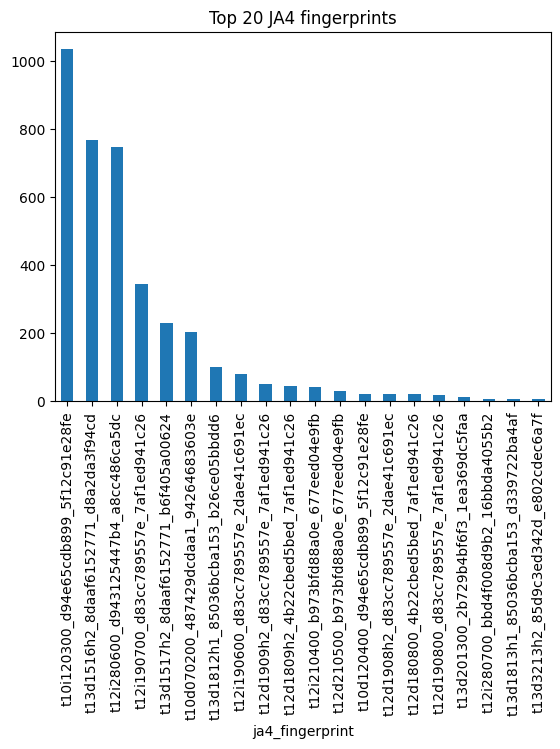

In [30]:
print("\nUnique JA4 fingerprints per label:\n")

print(
    df.groupby("label")["ja4_fingerprint"]
      .nunique()
      .sort_values(ascending=False)
)
top = df["ja4_fingerprint"].value_counts().head(20)

print(top)

top.plot(kind="bar")

plt.title("Top 20 JA4 fingerprints")

plt.show()

has_tls
0    31662
1     3877
Name: count, dtype: int64


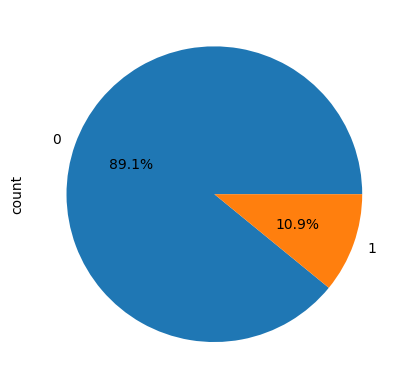

In [31]:
print(df["has_tls"].value_counts())

df["has_tls"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.show()

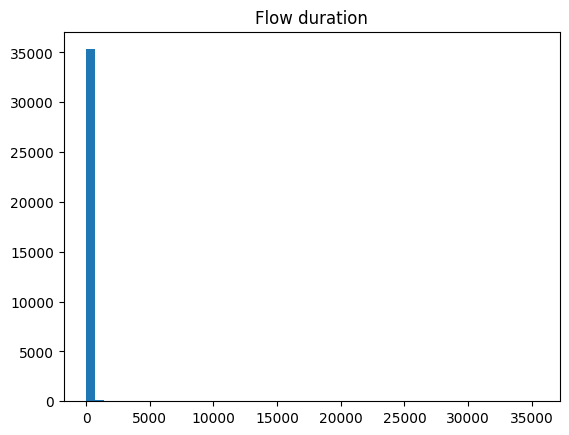

In [32]:
plt.hist(
    df["duration"],
    bins=50
)

plt.title("Flow duration")

plt.show()

In [33]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing)

ja4_fingerprint    31662
ja3_fingerprint    31662
dtype: int64


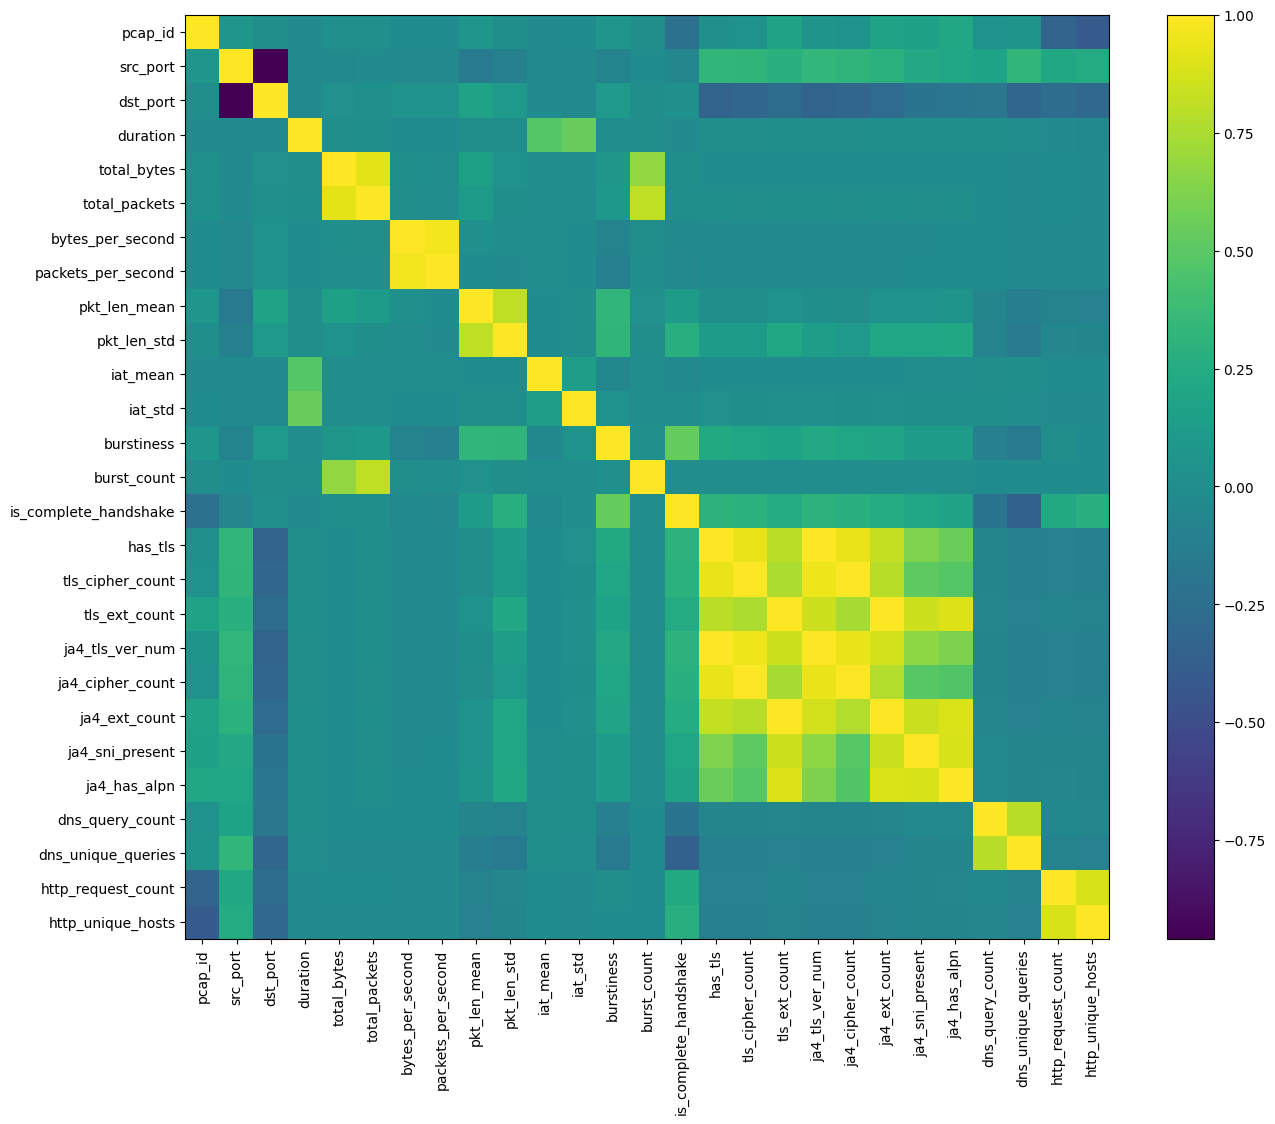

In [34]:
numeric = df.select_dtypes(include=np.number)

corr = numeric.corr()

plt.figure(figsize=(15, 12))

plt.imshow(corr)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.show()

In [35]:
print(
    df["pcap_id"]
    .value_counts()
)

pcap_id
3     6086
17    5833
31    3491
30    3189
29    3049
16    1797
20    1608
32    1371
7     1368
19    1131
4      854
25     810
15     711
28     701
6      651
26     526
5      518
2      415
10     345
27     267
11     221
18     125
14      82
1       72
9       72
23      66
13      42
12      32
24      32
8       30
21      26
22      18
Name: count, dtype: int64


In [36]:
numeric_features = [

    "duration",
    "total_bytes",
    "total_packets",
    "bytes_per_second",
    "packets_per_second",
    "pkt_len_mean",
    "pkt_len_std",
    "iat_mean",
    "iat_std",
    "burstiness",
    "burst_count",
    "is_complete_handshake",
    "has_tls",
    "tls_cipher_count",
    "tls_ext_count",
    "ja4_tls_ver_num",
    "ja4_cipher_count",
    "ja4_ext_count",
    "ja4_sni_present",
    "ja4_has_alpn",
    "dns_query_count",
    "dns_unique_queries",
    "http_request_count",
    "http_unique_hosts"
]

In [37]:
features = [
    "duration",
    "total_bytes",
    "total_packets",
    "bytes_per_second",
    "pkt_len_mean",
    "iat_mean",
    "tls_cipher_count",
]

for col in features:
    print("\n", col)
    print(
        df.groupby("label")[col]
          .describe()[["mean", "std"]]
    )


 duration
               mean          std
label                           
bengin    34.805006   114.235337
emotet    21.815945   275.260466
trickbot  80.480871  1126.704676

 total_bytes
                  mean           std
label                               
bengin    59337.779256  1.315720e+06
emotet    13780.583813  1.843527e+05
trickbot  19739.300145  3.027949e+05

 total_packets
               mean          std
label                           
bengin    65.258453  1217.865857
emotet    20.592648   170.578991
trickbot  22.768163   196.713012

 bytes_per_second
                   mean           std
label                                
bengin     25742.094579  2.231407e+05
emotet    143139.201809  2.305284e+06
trickbot   47383.921401  2.556171e+05

 pkt_len_mean
                mean         std
label                           
bengin    250.220588  267.469845
emotet    155.320978  325.156966
trickbot  204.926935  320.702287

 iat_mean
               mean         std
label       

In [38]:
from sklearn.feature_selection import mutual_info_classif

features = [
    "duration",
    "total_bytes",
    "total_packets",
    "bytes_per_second",
    "packets_per_second",
    "pkt_len_mean",
    "pkt_len_std",
    "iat_mean",
    "iat_std",
    "burstiness",
    "burst_count",
    "is_complete_handshake",
    "has_tls",
    "tls_cipher_count",
    "tls_ext_count",
    "ja4_tls_ver_num",
    "ja4_cipher_count",
    "ja4_ext_count",
    "ja4_sni_present",
    "ja4_has_alpn",
    "dns_query_count",
    "dns_unique_queries",
    "http_request_count",
    "http_unique_hosts",
]

scores = mutual_info_classif(
    df[features].fillna(0),
    df["label"]
)

result = (
    pd.DataFrame(
        {
            "feature": features,
            "score": scores
        }
    )
    .sort_values(
        "score",
        ascending=False
    )
)

print(result)

                  feature     score
1             total_bytes  0.616346
5            pkt_len_mean  0.593943
6             pkt_len_std  0.490847
0                duration  0.436718
3        bytes_per_second  0.374534
4      packets_per_second  0.358849
7                iat_mean  0.357548
8                 iat_std  0.306348
9              burstiness  0.294569
2           total_packets  0.155477
13       tls_cipher_count  0.115987
16       ja4_cipher_count  0.115019
14          tls_ext_count  0.111128
17          ja4_ext_count  0.110527
10            burst_count  0.108122
15        ja4_tls_ver_num  0.106275
11  is_complete_handshake  0.101857
22     http_request_count  0.078598
23      http_unique_hosts  0.072064
19           ja4_has_alpn  0.037436
20        dns_query_count  0.024837
21     dns_unique_queries  0.020184
18        ja4_sni_present  0.017267
12                has_tls  0.003620


In [39]:
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight



MAX_LEN = 64          # JA4 fingerprint max length
JA3_MAX_LEN = 32      # JA3 is always a 32-char md5 hex digest
EMBEDDING_DIM = 32

MAX_FLOWS_PER_PCAP = 1000

# Numeric / boolean flow features from the dataset. These carry signal for
# EVERY flow (TLS or not), unlike ja4_fingerprint which is empty whenever
# has_tls == 0. This is what lets the model tell non-TLS flows apart instead
# of collapsing them all onto the same all-<PAD> vector.
NUMERIC_FEATURES = [
    "duration",
    "total_bytes",
    "total_packets",
    "bytes_per_second",
    "packets_per_second",
    "pkt_len_mean",
    "pkt_len_std",
    "iat_mean",
    "iat_std",
    "burstiness",
    "burst_count",
    "is_complete_handshake",
    "has_tls",
    "tls_cipher_count",
    "tls_ext_count",
    "ja4_tls_ver_num",
    "ja4_cipher_count",
    "ja4_ext_count",
    "ja4_sni_present",
    "ja4_has_alpn",
    "dns_query_count",
    "dns_unique_queries",
    "http_request_count",
    "http_unique_hosts",
]

CATEGORICAL_FEATURES = ["protocol"]





# ============================================================
# LIMIT FLOWS PER PCAP
# ============================================================

# NOTE: we sample indices per group rather than whole sub-dataframes.
# Newer pandas (2.2+/3.0) drops the grouping column from the sub-frame
# passed into groupby(...).apply(...), which silently loses "pcap_id"
# if you sample and return the sub-dataframe directly. Sampling the
# index and then re-selecting from the original df sidesteps that and
# works the same way across pandas versions.
sampled_idx_per_group = df.groupby("pcap_id").apply(
    lambda x: x.sample(n=min(len(x), MAX_FLOWS_PER_PCAP), random_state=42).index
)
all_sampled_idx = np.concatenate(sampled_idx_per_group.values)
df = df.loc[all_sampled_idx].reset_index(drop=True)

print("Rows after balancing:", len(df))



# ============================================================
# TOKENIZER (for ja4_fingerprint text branch)
# ============================================================

class FingerprintTokenizer:
    """Generic char-level tokenizer, reused for both ja4_fingerprint and
    ja3_fingerprint (each gets its own instance/vocabulary/max_len, since
    the two strings have different structure and length)."""

    def __init__(self, max_len):
        self.max_len = max_len
        self.char_to_id = {
            "<PAD>": 0,
            "<UNK>": 1,
        }

    def fit(self, texts):
        for text in texts:
            text = "" if pd.isna(text) else str(text)
            for ch in text:
                if ch not in self.char_to_id:
                    self.char_to_id[ch] = len(self.char_to_id)

    def encode(self, text):
        text = "" if pd.isna(text) else str(text)
        ids = [
            self.char_to_id.get(ch, self.char_to_id["<UNK>"])
            for ch in text
        ]
        if len(ids) > self.max_len:
            ids = ids[:self.max_len]
        padded = np.zeros(self.max_len, dtype=np.int32)
        padded[:len(ids)] = ids
        return padded


# ============================================================
# ENCODE LABELS
# ============================================================

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["label"])

print("\nClasses:")
print(label_encoder.classes_)


# ============================================================
# SPLIT USING PCAP ID (done BEFORE fitting any tokenizer/scaler/encoder,
# so nothing about the test set leaks into what gets fit on train)
# ============================================================

groups = df["pcap_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(df, y, groups=groups)
)

df_train = df.iloc[train_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

y_train = y[train_idx]
y_test = y[test_idx]

print("\nTrain size:", len(df_train))
print("Test size:", len(df_test))

print("\nTrain PCAP count:", df_train["pcap_id"].nunique())
print("Test PCAP count:", df_test["pcap_id"].nunique())

print("\nTrain labels:")
print(df_train["label"].value_counts())

print("\nTest labels:")
print(df_test["label"].value_counts())


# ============================================================
# JA4 TEXT BRANCH: fit tokenizer on TRAIN ONLY, encode both splits
# ============================================================

ja4_tokenizer = FingerprintTokenizer(max_len=MAX_LEN)
ja4_tokenizer.fit(df_train["ja4_fingerprint"].fillna("").astype(str).tolist())

X_ja4_train = np.vstack(df_train["ja4_fingerprint"].apply(ja4_tokenizer.encode))
X_ja4_test = np.vstack(df_test["ja4_fingerprint"].apply(ja4_tokenizer.encode))

print("\nJA4 encoded shape (train):", X_ja4_train.shape)
print("JA4 vocabulary size:", len(ja4_tokenizer.char_to_id))


# ============================================================
# JA3 TEXT BRANCH: same idea as JA4, separate tokenizer/vocab since JA3
# is a plain md5 hex digest (different alphabet/structure than JA4).
# Like ja4_fingerprint, ja3_fingerprint is "" for non-TLS flows, and that
# empty string encodes to an all-<PAD> vector -- fine here because this
# branch is combined with the numeric/categorical branch, which still
# carries signal for those flows.
# ============================================================

ja3_tokenizer = FingerprintTokenizer(max_len=JA3_MAX_LEN)
ja3_tokenizer.fit(df_train["ja3_fingerprint"].fillna("").astype(str).tolist())

X_ja3_train = np.vstack(df_train["ja3_fingerprint"].apply(ja3_tokenizer.encode))
X_ja3_test = np.vstack(df_test["ja3_fingerprint"].apply(ja3_tokenizer.encode))

print("\nJA3 encoded shape (train):", X_ja3_train.shape)
print("JA3 vocabulary size:", len(ja3_tokenizer.char_to_id))


# ============================================================
# NUMERIC / CATEGORICAL BRANCH
# ============================================================

# Missing numeric values (e.g. a non-TLS flow having no tls_cipher_count
# recorded, or a NaN slipping in from upstream) are filled with 0 rather
# than dropped, so we never lose whole rows just because one column is
# absent for that flow type.
train_numeric_df = df_train[NUMERIC_FEATURES].apply(pd.to_numeric, errors="coerce").fillna(0.0)
test_numeric_df = df_test[NUMERIC_FEATURES].apply(pd.to_numeric, errors="coerce").fillna(0.0)

scaler = StandardScaler()
X_num_train = scaler.fit_transform(train_numeric_df.values)
X_num_test = scaler.transform(test_numeric_df.values)

# Protocol (TCP/UDP/ICMP/...) is categorical -> one-hot. handle_unknown
#="ignore" means a protocol seen only at test time just becomes an
# all-zero vector instead of crashing.
cat_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
train_cat_df = df_train[CATEGORICAL_FEATURES].fillna("UNKNOWN").astype(str)
test_cat_df = df_test[CATEGORICAL_FEATURES].fillna("UNKNOWN").astype(str)

X_cat_train = cat_encoder.fit_transform(train_cat_df.values)
X_cat_test = cat_encoder.transform(test_cat_df.values)

X_num_train = np.hstack([X_num_train, X_cat_train]).astype(np.float32)
X_num_test = np.hstack([X_num_test, X_cat_test]).astype(np.float32)

NUM_INPUT_DIM = X_num_train.shape[1]
print("\nNumeric/categorical feature vector size:", NUM_INPUT_DIM)


# ============================================================
# CLASS WEIGHTS (imbalance is still real on top of the missing-branch fix)
# ============================================================

class_weight_values = compute_class_weight(
    "balanced",
    classes=np.unique(y_train),
    y=y_train,
)
class_weight = {i: w for i, w in enumerate(class_weight_values)}
print("\nClass weights:", class_weight)


# ============================================================
# MODEL: three input branches concatenated before the classifier head
# ============================================================

# --- Branch A: character-level CNN over the JA4 fingerprint string ---
ja4_input = tf.keras.layers.Input(shape=(MAX_LEN,), name="ja4_input")

x = tf.keras.layers.Embedding(
    input_dim=len(ja4_tokenizer.char_to_id),
    output_dim=EMBEDDING_DIM,
)(ja4_input)

x = tf.keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", activation="relu")(x)
x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)
x = tf.keras.layers.Conv1D(filters=128, kernel_size=3, padding="same", activation="relu")(x)
x = tf.keras.layers.GlobalMaxPooling1D()(x)
ja4_branch_out = tf.keras.layers.Dense(64, activation="relu")(x)

# --- Branch B: character-level CNN over the JA3 fingerprint string ---
# Own Embedding/Conv1D stack (separate weights from the JA4 branch) since
# JA3 is a different alphabet/format (md5 hex) with its own vocabulary.
ja3_input = tf.keras.layers.Input(shape=(JA3_MAX_LEN,), name="ja3_input")

j3 = tf.keras.layers.Embedding(
    input_dim=len(ja3_tokenizer.char_to_id),
    output_dim=EMBEDDING_DIM,
)(ja3_input)

j3 = tf.keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", activation="relu")(j3)
j3 = tf.keras.layers.MaxPooling1D(pool_size=2)(j3)
j3 = tf.keras.layers.Conv1D(filters=128, kernel_size=3, padding="same", activation="relu")(j3)
j3 = tf.keras.layers.GlobalMaxPooling1D()(j3)
ja3_branch_out = tf.keras.layers.Dense(64, activation="relu")(j3)

# --- Branch C: MLP over the numeric/categorical flow features ---
numeric_input = tf.keras.layers.Input(shape=(NUM_INPUT_DIM,), name="numeric_input")

n = tf.keras.layers.Dense(64, activation="relu")(numeric_input)
n = tf.keras.layers.Dropout(0.3)(n)
numeric_branch_out = tf.keras.layers.Dense(32, activation="relu")(n)

# --- Combine ---
combined = tf.keras.layers.Concatenate()([ja4_branch_out, ja3_branch_out, numeric_branch_out])
combined = tf.keras.layers.Dense(64, activation="relu")(combined)
combined = tf.keras.layers.Dropout(0.3)(combined)
output = tf.keras.layers.Dense(len(label_encoder.classes_), activation="softmax")(combined)

model = tf.keras.Model(inputs=[ja4_input, ja3_input, numeric_input], outputs=output)


# ============================================================
# COMPILE
# ============================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()


# ============================================================
# TRAIN
# ============================================================

history = model.fit(
    {"ja4_input": X_ja4_train, "ja3_input": X_ja3_train, "numeric_input": X_num_train},
    y_train,
    validation_data=(
        {"ja4_input": X_ja4_test, "ja3_input": X_ja3_test, "numeric_input": X_num_test},
        y_test,
    ),
    epochs=15,
    batch_size=128,
    class_weight=class_weight,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=3,
            restore_best_weights=True,
        )
    ],
)


# ============================================================
# EVALUATE
# ============================================================

probs = model.predict({"ja4_input": X_ja4_test, "ja3_input": X_ja3_test, "numeric_input": X_num_test})
pred = np.argmax(probs, axis=1)

print("\nClassification report:\n")
print(
    classification_report(
        y_test,
        pred,
        target_names=label_encoder.classes_,
        digits=4,
    )
)

print("\nConfusion matrix:\n")
print(confusion_matrix(y_test, pred))

Rows after balancing: 16616

Classes:
['bengin' 'emotet' 'trickbot']

Train size: 12264
Test size: 4352

Train PCAP count: 25
Test PCAP count: 7

Train labels:
label
trickbot    5477
emotet      4086
bengin      2701
Name: count, dtype: int64

Test labels:
label
bengin      2000
emotet      1542
trickbot     810
Name: count, dtype: int64

JA4 encoded shape (train): (12264, 64)
JA4 vocabulary size: 22

JA3 encoded shape (train): (12264, 32)
JA3 vocabulary size: 18


C:\Users\HP\AppData\Local\Temp\ipykernel_3340\1343426399.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_idx_per_group = df.groupby("pcap_id").apply(



Numeric/categorical feature vector size: 27

Class weights: {0: np.float64(1.5135135135135136), 1: np.float64(1.0004894762604013), 2: np.float64(0.7463940113200658)}


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ja4_input           │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ja3_input           │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_14        │ (None, 64, 32)    │        704 │ ja4_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_15        │ (None, 32, 32)    │        576 │ ja3_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_28 (Conv1D)  │ (None, 64, 64)    │     10,304 │ embedding_14[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_30 (Conv1D)  │ (None, 32, 64)    │     10,304 │ embedding_15[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_14    │ (None, 32, 64)    │          0 │ conv1d_28[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_15    │ (None, 16, 64)    │          0 │ conv1d_30[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_input       │ (None, 27)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_29 (Conv1D)  │ (None, 32, 128)   │     24,704 │ max_pooling1d_14… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_31 (Conv1D)  │ (None, 16, 128)   │     24,704 │ max_pooling1d_15… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_44 (Dense)    │ (None, 64)        │      1,792 │ numeric_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_29[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_31[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 64)        │          0 │ dense_44[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_42 (Dense)    │ (None, 64)        │      8,256 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_43 (Dense)    │ (None, 64)        │      8,256 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_45 (Dense)    │ (None, 32)        │      2,080 │ dropout_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 160)       │          0 │ dense_42[0][0],   │
│ (Concatenate)       │                   │            │ dense_43[0][0],   │
│                     │                   │            │ dense_45[0][0]  

 Total params: 102,179 (399.14 KB)

 Trainable params: 102,179 (399.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.5979 - loss: 0.9043 - val_accuracy: 0.4566 - val_loss: 0.9960
Epoch 2/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6641 - loss: 0.7811 - val_accuracy: 0.4577 - val_loss: 0.9475
Epoch 3/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6742 - loss: 0.7577 - val_accuracy: 0.6041 - val_loss: 0.9530
Epoch 4/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6777 - loss: 0.7482 - val_accuracy: 0.6301 - val_loss: 0.8821
Epoch 5/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6853 - loss: 0.7268 - val_accuracy: 0.6284 - val_loss: 0.8766
Epoch 6/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6940 - loss: 0.7169 - val_accuracy: 0.6409 - val_loss: 0.8519
Epoch 7/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6975 - loss: 0.7018 - val_accuracy: 0.6652 - val_loss: 0.8286
Epoch 8/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7026 - loss: 0.6867 - val_accuracy: 0.6560 - v

In [48]:
print(
    df.groupby("label")["pcap_id"].nunique()
)
print(df.groupby(["label", "pcap_id"]).size())

label
bengin       5
emotet      12
trickbot    15
Name: pcap_id, dtype: int64
label     pcap_id
bengin    28          701
          29         1000
          30         1000
          31         1000
          32         1000
emotet    8            30
          9            72
          10          345
          11          221
          13           42
          14           82
          15          711
          16         1000
          17         1000
          18          125
          19         1000
          20         1000
trickbot  1            72
          2           415
          3          1000
          4           854
          5           518
          6           651
          7          1000
          12           32
          21           26
          22           18
          23           66
          24           32
          25          810
          26          526
          27          267
dtype: int64


In [41]:
test_df = df.iloc[test_idx]

print(
    test_df.groupby("label")["pcap_id"].unique()
)

label
bengin             [30, 31]
emotet      [9, 10, 16, 18]
trickbot               [25]
Name: pcap_id, dtype: object


In [42]:
test_df = df.iloc[test_idx]

print(
    test_df.groupby(
        ["label", "pcap_id"]
    ).size()
)

label     pcap_id
bengin    30         1000
          31         1000
emotet    9            72
          10          345
          16         1000
          18          125
trickbot  25          810
dtype: int64


In [43]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# ==========================================
# FEATURES
# ==========================================

# ==========================================
# FEATURES (low-performing features removed)
# ==========================================

features = [

    # Flow statistics
    "duration",
    "total_bytes",
    "total_packets",

    "bytes_per_second",
    "packets_per_second",

    # Packet statistics
    "pkt_len_mean",
    "pkt_len_std",

    # Timing
    "iat_mean",
    "iat_std",

    # Burst features
    "burstiness",
    "burst_count",

    # Handshake
    "is_complete_handshake",

    # TLS features
    "tls_cipher_count",
    "tls_ext_count",

    # JA4 numeric features
    "ja4_tls_ver_num",
    "ja4_cipher_count",
    "ja4_ext_count",
]


# ==========================================
# PREPROCESSING
# ==========================================

X = df[features].fillna(0)

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(
    df["label"]
)

groups = df["pcap_id"]


# ==========================================
# SPLIT BY PCAP
# ==========================================

splitter = GroupShuffleSplit(

    n_splits=1,
    test_size=0.2,
    random_state=42

)

train_idx, test_idx = next(

    splitter.split(
        X,
        y,
        groups=groups
    )

)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]


print("\nTrain labels:")

print(
    df.iloc[train_idx]["label"]
    .value_counts()
)

print("\nTest labels:")

print(
    df.iloc[test_idx]["label"]
    .value_counts()
)


# ==========================================
# SCALE FEATURES
# ==========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)


# ==========================================
# MODELS
# ==========================================

models = {

    "Random Forest": RandomForestClassifier(

        n_estimators=300,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(

        n_estimators=300,
        max_depth=8,

        learning_rate=0.05,

        subsample=0.8,

        colsample_bytree=0.8,

        random_state=42
    ),

    "LightGBM": LGBMClassifier(

        n_estimators=300,

        learning_rate=0.05,

        num_leaves=31,

        random_state=42
    )

}


# ==========================================
# TRAIN AND TEST
# ==========================================

for name, model in models.items():

    print("\n")
    print("=" * 60)

    print(name)

    print("=" * 60)

    model.fit(

        X_train,
        y_train

    )

    pred = model.predict(
        X_test
    )

    print("\nClassification report:\n")

    print(

        classification_report(

            y_test,

            pred,

            target_names=label_encoder.classes_,

            digits=4

        )

    )

    print("\nConfusion matrix:\n")

    print(

        confusion_matrix(

            y_test,
            pred

        )

    )


Train labels:
label
trickbot    5477
emotet      4086
bengin      2701
Name: count, dtype: int64

Test labels:
label
bengin      2000
emotet      1542
trickbot     810
Name: count, dtype: int64


Random Forest

Classification report:

              precision    recall  f1-score   support

      bengin     0.9042    0.8450    0.8736      2000
      emotet     0.7539    0.6816    0.7159      1542
    trickbot     0.5344    0.7185    0.6130       810

    accuracy                         0.7636      4352
   macro avg     0.7309    0.7484    0.7342      4352
weighted avg     0.7822    0.7636    0.7692      4352


Confusion matrix:

[[1690  190  120]
 [ 104 1051  387]
 [  75  153  582]]


XGBoost

Classification report:

              precision    recall  f1-score   support

      bengin     0.9068    0.8370    0.8705      2000
      emotet     0.7340    0.6712    0.7012      1542
    trickbot     0.5237    0.7086    0.6023       810

    accuracy                         0.7544      4352
 

In [44]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier




# ==========================================================
# FEATURES
# ==========================================================

features = [

    "duration",
    "total_bytes",
    "total_packets",

    "bytes_per_second",
    "packets_per_second",

    "pkt_len_mean",
    "pkt_len_std",

    "iat_mean",
    "iat_std",

    "burstiness",
    "burst_count",

    "is_complete_handshake",

    "tls_cipher_count",
    "tls_ext_count",

    "ja4_tls_ver_num",
    "ja4_cipher_count",
    "ja4_ext_count",

]


# ==========================================================
# PREPROCESS
# ==========================================================

X = df[features].fillna(0)

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(
    df["label"]
)

print("\nClasses:")

print(
    label_encoder.classes_
)


# ==========================================================
# RANDOM SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y,

    shuffle=True

)


# ==========================================================
# SHOW LABEL DISTRIBUTION
# ==========================================================

train_labels = label_encoder.inverse_transform(
    y_train
)

test_labels = label_encoder.inverse_transform(
    y_test
)

print("\nTrain size:", len(X_train))
print("Test size:", len(X_test))

print("\nTrain labels:")

print(
    pd.Series(
        train_labels
    ).value_counts()
)

print("\nTest labels:")

print(
    pd.Series(
        test_labels
    ).value_counts()
)


# ==========================================================
# SCALE
# ==========================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)


# ==========================================================
# MODELS
# ==========================================================

models = {

    "Random Forest": RandomForestClassifier(

        n_estimators=300,

        max_depth=20,

        random_state=42,

        n_jobs=-1

    ),

    "XGBoost": XGBClassifier(

        n_estimators=300,

        max_depth=8,

        learning_rate=0.05,

        subsample=0.8,

        colsample_bytree=0.8,

        random_state=42

    ),

    "LightGBM": LGBMClassifier(

        n_estimators=300,

        learning_rate=0.05,

        num_leaves=31,

        random_state=42

    )

}


# ==========================================================
# TRAIN + TEST
# ==========================================================

for name, model in models.items():

    print("\n")
    print("=" * 60)

    print(name)

    print("=" * 60)

    model.fit(

        X_train,
        y_train

    )

    pred = model.predict(
        X_test
    )

    print("\nClassification report:\n")

    print(

        classification_report(

            y_test,

            pred,

            target_names=label_encoder.classes_,

            digits=4

        )

    )

    print("\nConfusion matrix:\n")

    print(

        confusion_matrix(

            y_test,
            pred

        )

    )


Classes:
['bengin' 'emotet' 'trickbot']

Train size: 13292
Test size: 3324

Train labels:
trickbot    5029
emotet      4502
bengin      3761
Name: count, dtype: int64

Test labels:
trickbot    1258
emotet      1126
bengin       940
Name: count, dtype: int64


Random Forest

Classification report:

              precision    recall  f1-score   support

      bengin     0.8927    0.8319    0.8612       940
      emotet     0.8021    0.8748    0.8369      1126
    trickbot     0.9148    0.8871    0.9007      1258

    accuracy                         0.8673      3324
   macro avg     0.8699    0.8646    0.8663      3324
weighted avg     0.8704    0.8673    0.8679      3324


Confusion matrix:

[[ 782  129   29]
 [  66  985   75]
 [  28  114 1116]]


XGBoost

Classification report:

              precision    recall  f1-score   support

      bengin     0.9035    0.8266    0.8633       940
      emotet     0.8021    0.8783    0.8385      1126
    trickbot     0.9074    0.8879    0.8975   